# Netflix Recommendation System
### Content-Based Recommendation using TF-IDF and Cosine Similarity

**Name:** Nirmalashree M  
**Internship:** AIML  
**Submission Date:** 25 Feb 2026

# 1. Introduction

Netflix is one of the largest streaming platforms offering movies and TV shows across multiple genres and countries.

With thousands of titles available, it becomes difficult for users to decide what to watch.

This project aims to analyze the Netflix dataset and build a recommendation system that suggests similar content based on textual features such as genre and description.

# 2. Problem Statement

The objective of this project is:

- To perform exploratory data analysis on the Netflix dataset.
- To clean and preprocess the dataset.
- To build a content-based recommendation system.
- To recommend similar movies or TV shows using text similarity techniques.

# 3. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings("ignore")

# 4. Data Loading

In [ ]:
df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


# 5. Data Understanding


In [ ]:
df.shape
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


,0
show_id,0
type,0
title,0
director,2389
cast,718
country,507
date_added,10
release_year,0
rating,7
duration,0


The dataset contains information about Netflix titles including:
- Title
- Director
- Cast
- Country
- Release year
- Rating
- Genre (listed_in)
- Description

We observe missing values in columns such as director, cast, and country.

# 6. Data Cleaning

In [ ]:
def clean_data(df):
    df = df.copy()

    df['director'].fillna('Unknown', inplace=True)
    df['cast'].fillna('Unknown', inplace=True)
    df['country'].fillna('Unknown', inplace=True)
    df['rating'].fillna(df['rating'].mode()[0], inplace=True)

    df['content'] = df['listed_in'] + " " + df['description']

    return df

df = clean_data(df)

Missing values were handled by replacing them with:
- "Unknown" for categorical columns
- Mode for rating column

This ensures the dataset has no null values before modeling.

# 7. Exploratory Data Analysis (EDA)

7.1 Movies vs TV Shows

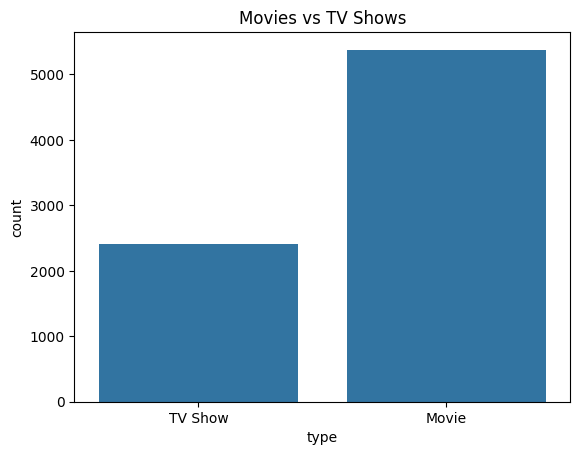

In [ ]:
sns.countplot(x='type', data=df)
plt.title("Movies vs TV Shows")
plt.show()

Observation:
Netflix contains more Movies than TV Shows.

7.2 Top 10 Countries


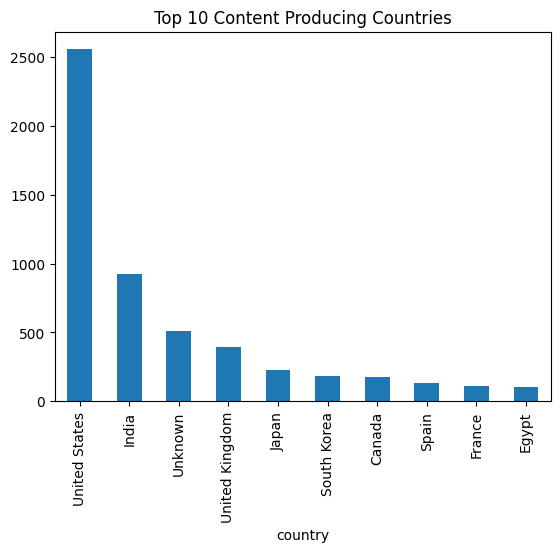

In [ ]:
df['country'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Content Producing Countries")
plt.show()

Observation:
The United States produces the highest number of titles.

7.3 Ratings Distribution

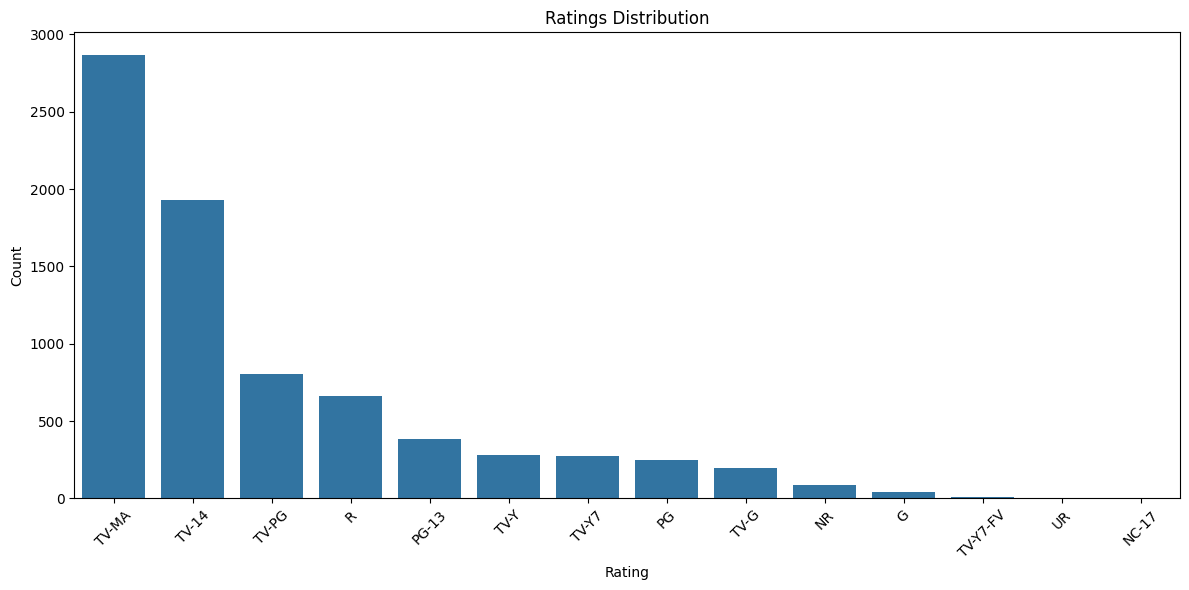

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='rating',
    data=df,
    order=df['rating'].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Observation:
TV-MA and TV-14 are the most common ratings.

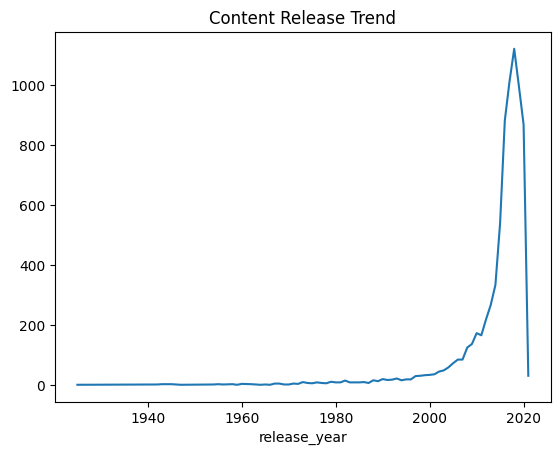

In [ ]:
df['release_year'].value_counts().sort_index().plot()
plt.title("Content Release Trend")
plt.show()

Observation:
There is a rapid increase in content after 2015.

# 8. Feature Engineering

To build the recommendation system, we combine:
- Genre information (listed_in)
- Description

This combined text is used for TF-IDF vectorization.

In [ ]:
df['content'] = df['listed_in'] + " " + df['description']
df[['title', 'content']].head()

,title,content
0,3%,"International TV Shows, TV Dramas, TV Sci-Fi &..."
1,7:19,"Dramas, International Movies After a devastati..."
2,23:59,"Horror Movies, International Movies When an ar..."
3,9,"Action & Adventure, Independent Movies, Sci-Fi..."
4,21,Dramas A brilliant group of students become ca...


# 9. Model Building

We build a Content-Based Recommendation System using:

1. TF-IDF Vectorization – converts text into numerical features.
2. Cosine Similarity – measures similarity between content vectors.

9.1 TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['content'])

9.2 Cosine Similarity

In [ ]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

9.3 Create Index Mapping

In [ ]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

# 10. Recommendation Function

In [ ]:
def recommend(title, top_n=5):
    if title not in indices:
        return "Title not found"

    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    movie_indices = [i[0] for i in sim_scores]
    return df['title'].iloc[movie_indices]

# 11. Model Evaluation

In [ ]:
average_similarity = np.mean(cosine_sim)
print("Average Similarity Score:", average_similarity)

Average Similarity Score: 0.019460010923628434


The average similarity score represents overall similarity between content vectors in the dataset.

# 12. Recommendation Demo

In [ ]:
recommend("Narcos", 5)

,title
4402,Narcos: Mexico
1947,El Cartel 2
4134,Miss Dynamite
1948,El Chapo
685,Bad Blood


# 13. Conclusion

- Netflix has more movies than TV shows.
- USA produces the highest number of content.
- Drama and International genres are very common.
- The content-based recommendation system successfully suggests similar content using TF-IDF and cosine similarity.

This approach works well when user interaction data is not available.

# 14. Future Improvements

- Add collaborative filtering.
- Use deep learning embeddings (BERT).
- Deploy the system as a web application.
- Use hybrid recommendation techniques.